# **Simulating Light GBM Software Running**

Python implementation of predicting classification of known input, using known lgbm model, in order to compare performance with designed hardware accelerator.
The simulation make use of the library "lightgbm" which is highly optimized.
* Known input and model: Those were set according to the case described in our Project Report, Verification Chapter.
Illustration for class 0 predictor:
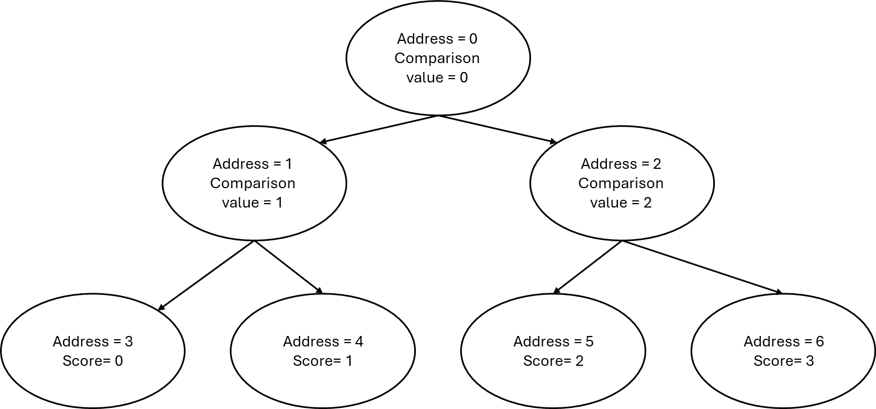

**Results**:
1. Single classification: Latency is approximately **150-200** $\mu$s.
2. Average multiple classifications: Average classification time is approximately **50-100** $\mu$s.

**Conclusions**:

The single-classification metric provides a more realistic baseline for hardware comparison. While the loop-averaged software execution yields higher performance due to aggressive CPU caching and branch prediction optimizations, practical real-time deployment scenarios rarely process identical inputs sequentially. Even when compared against the optimized software average, our custom accelerator processes the input in 0.7 $\mu$s (52 clock cycles at a operating frequency of 66.67 MHz), significantly outperforming the software baseline.

**Simulation Notes:**
1. Please execute the code cells in **Google Colab** to reproduce the results immediately. Ensure the cells are run in descending order.
2. Running the third code cell will result in the **creation of 2 .txt files** inside the Files/sample_data directory in Google Colab. These temporary files are utilized during the simulation and may be safely deleted upon completion.

In [39]:
import lightgbm
print(lightgbm.__version__)

4.6.0


In [42]:
# assumes lgb ver 4.6.0
import lightgbm as lgb
import numpy as np

# =====================================================================
# Model Generating Function
# =====================================================================

def create_custom_gbdt():
    num_classes = 32
    num_features = 256

    # ---------------------------------------------------------
    # 1. Train a "Dummy" Model to get a perfect Header
    # ---------------------------------------------------------
    # Create tiny dummy data just to force LightGBM to initialize
    X_dummy = np.zeros((10, num_features))
    y_dummy = np.zeros(10)

    train_data = lgb.Dataset(X_dummy, label=y_dummy)
    params = {
        'objective': 'multiclass',
        'num_class': num_classes,
        'verbosity': -1
    }

    # 1 boost round with 32 classes generates exactly 32 trees
    dummy_bst = lgb.train(params, train_data, num_boost_round=1)
    dummy_bst.save_model('dummy_template.txt')

    # ---------------------------------------------------------
    # 2. Extract the valid Header
    # ---------------------------------------------------------
    with open('dummy_template.txt', 'r') as f:
        template = f.read()

    # The header is everything before the first "Tree=0" begins
    header = template.split('Tree=0\n')[0]

    # Remove the old tree_sizes line (we must recalculate it)
    header_lines = [line for line in header.split('\n') if not line.startswith('tree_sizes=')]
    header = '\n'.join(header_lines)
    if not header.endswith('\n'):
        header += '\n'

    # ---------------------------------------------------------
    # 3. Generate Custom Trees & Calculate Sizes
    # ---------------------------------------------------------
    tree_strings = []
    for c in range(num_classes):
        tree_str = f"Tree={c}\n"
        tree_str += "num_leaves=4\n"
        tree_str += "num_cat=0\n"

        # c * 3 logic for 3 non-leaf nodes
        features = [c * 3 + i for i in range(3)]
        tree_str += f"split_feature={' '.join(map(str, features))}\n"

        # Using explicit floats (.0) prevents parser integer errors
        tree_str += "split_gain=0.1 0.1 0.1\n"
        tree_str += f"threshold={' '.join(map(str, [float(feat) for feat in features]))}\n"
        tree_str += "decision_type=2 2 2\n"
        tree_str += "left_child=1 -1 -3\n"
        tree_str += "right_child=2 -2 -4\n"

        leaf_values = [float(c * 4 + i) for i in range(4)]
        tree_str += f"leaf_value={' '.join(map(str, leaf_values))}\n"

        tree_str += "leaf_weight=1.0 1.0 1.0 1.0\n"
        tree_str += "leaf_count=1 1 1 1\n"
        tree_str += "internal_value=0.0 0.0 0.0\n"
        tree_str += "internal_weight=1.0 1.0 1.0\n"
        tree_str += "internal_count=1 1 1\n"
        tree_str += "is_linear=0\n"
        tree_str += "shrinkage=1\n\n"

        tree_strings.append(tree_str)

    # LightGBM requires exact byte sizes for its internal C++ memory allocation
    tree_sizes = [len(ts.encode('utf-8')) for ts in tree_strings]
    tree_sizes_str = f"tree_sizes={' '.join(map(str, tree_sizes))}\n\n"

    # ---------------------------------------------------------
    # 4. Combine and Save the Final Model
    # ---------------------------------------------------------
    final_model_path = 'gbdt_simulation_model_fixed.txt'
    with open(final_model_path, 'w') as f:
        f.write(header)
        f.write(tree_sizes_str)
        for ts in tree_strings:
            f.write(ts)

    print(f"Model successfully saved to {final_model_path}")
    return final_model_path

In [43]:
# =====================================================================
# Execution & Testing
# =====================================================================

# 1. Build the model file
model_path = create_custom_gbdt()

# 2. Safely load it
try:
    bst = lgb.Booster(model_file=model_path)
    print("Booster loaded successfully into memory!\n")
    print("-" * 50)
except Exception as e:
    raise RuntimeError(f"Failed to load model: {e}")

# 3. Test Inference
num_features = 256
import time

# Create the specific input vector (all 1s)
input_data = np.ones((1, num_features))

# Warm-Up
_ = bst.predict(input_data)

# ---------------------------------------------------------
# 1. SINGLE RUN
# ---------------------------------------------------------

# Measure
start_time = time.perf_counter()
prediction = bst.predict(input_data)
end_time = time.perf_counter()

elapsed_time_ms = (end_time - start_time) * 1e6 #sec -> micro sec

print(f"Time taken for single classification: {elapsed_time_ms:.4f} micro seconds")

predicted_class = np.argmax(prediction)
print(f"Predicted Class: {predicted_class} (Hex: {hex(predicted_class)})")
print("-" * 50)

# ---------------------------------------------------------
# 2. AVG MULTIPLE RUNS
# ---------------------------------------------------------

times = []
tries = 100000
for _ in range(tries):
    start = time.perf_counter()
    bst.predict(input_data)
    end = time.perf_counter()
    times.append(end - start)

avg_time_ms = (sum(times) / len(times)) * 1e6 #sec -> micro sec
print(f"Average Classification time over {tries} runs: {avg_time_ms:.4f} micro seconds")

Model successfully saved to gbdt_simulation_model_fixed.txt
Booster loaded successfully into memory!

--------------------------------------------------
Time taken for single classification: 171.4870 micro seconds
Predicted Class: 31 (Hex: 0x1f)
--------------------------------------------------
Average Classification time over 100000 runs: 56.8739 micro seconds
